# Part 2 – Computer Vision Problem Formulation and CNN Prototype
### Dataset: Synthetic Manufacturing Defect Image Dataset
**Dataset Source:** [Google Drive Folder](https://drive.google.com/drive/folders/1akV6po4Nrgkc3yQrJkzA6cJlV-wBvUYs?usp=sharing)

---

## Task 1: Problem Identification

### Problem Type: **Image Classification**

This dataset contains product surface images labelled into four mutually exclusive categories. The goal is to train a model that, given a new product image, predicts which defect class it belongs to.

| CV Problem Type | Description | This Dataset |
|---|---|---|
| **Image Classification** | Assign one label to the whole image | ✅ Yes – each image has one class label |
| Object Detection | Locate objects with bounding boxes | ❌ No bounding box annotations |
| Semantic Segmentation | Classify every pixel | ❌ No pixel-level masks |
| Instance Segmentation | Mask each individual object | ❌ No instance masks |

**Classes:**
- `normal` – product surface without major defect  
- `scratch` – surface with scratch-like marks  
- `dent` – surface with circular dent-like marks  
- `stain` – surface with colored stain-like marks

In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────────
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.21.0
GPU        : []


In [2]:
# ── Cell 2: Configuration ──────────────────────────────────────────────────────
# ⚠️  Update DATASET_DIR to the folder containing images/ and labels.csv
DATASET_DIR = r'C:\Users\ASUS\Downloads\part-2-cnn-computer-vision\part-2-cnn-computer-vision'

IMG_DIR    = os.path.join(DATASET_DIR, 'images')
LABELS_CSV = os.path.join(DATASET_DIR, 'labels.csv')

CLASS_NAMES = ['normal', 'scratch', 'dent', 'stain']
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 30
VAL_SPLIT   = 0.2
LR          = 1e-3

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

## Task 2: Dataset Exploration

In [3]:
# ── Cell 3: Load labels.csv & class counts ─────────────────────────────────────
df = pd.read_csv(LABELS_CSV)
print(df.head(8))
print(f"\nTotal images : {len(df)}")
print(f"Columns      : {list(df.columns)}\n")

counts = df['class'].value_counts()
print("Images per class:")
for cls, cnt in counts.items():
    print(f"  {cls:<10} : {cnt}")

ratio = counts.max() / counts.min()
print(f"\nMax/Min ratio : {ratio:.2f}x  →  {'✅ Balanced' if ratio < 1.5 else '⚠️ Imbalanced – augmentation recommended'}")

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal
5  images/normal/normal_006.png  normal
6  images/normal/normal_007.png  normal
7  images/normal/normal_008.png  normal

Total images : 480
Columns      : ['filename', 'class']

Images per class:
  normal     : 120
  scratch    : 120
  dent       : 120
  stain      : 120

Max/Min ratio : 1.00x  →  ✅ Balanced


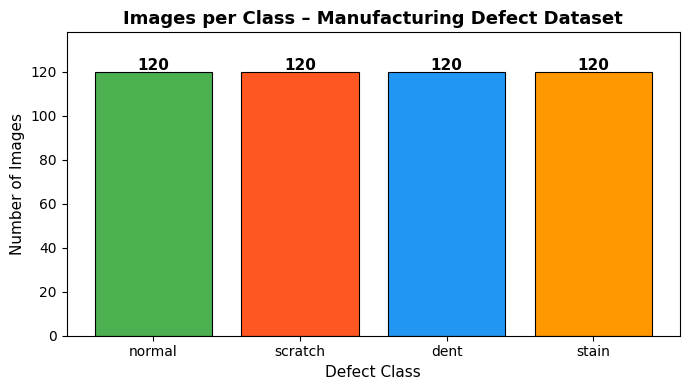

In [4]:
# ── Cell 4: Class Distribution Chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#4CAF50', '#FF5722', '#2196F3', '#FF9800']
ordered = [counts[c] for c in CLASS_NAMES]
bars = ax.bar(CLASS_NAMES, ordered, color=palette, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, ordered):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold', fontsize=11)
ax.set_title('Images per Class – Manufacturing Defect Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Defect Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_ylim(0, max(ordered) * 1.15)
plt.tight_layout()
plt.savefig('./results/class_distribution.png', dpi=150)
plt.show()

In [5]:
# ── Cell 5: Image Dimensions Analysis ─────────────────────────────────────────
sample_paths = df['filename'].sample(min(100, len(df)), random_state=SEED).tolist()
widths, heights = [], []
for rel_path in sample_paths:
    full_path = os.path.join(DATASET_DIR, rel_path)
    try:
        w, h = Image.open(full_path).size
        widths.append(w); heights.append(h)
    except Exception:
        pass

print(f"Width  – min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}")
print(f"Height – min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}")
print(f"\nAll images will be resized to {IMG_SIZE[0]}x{IMG_SIZE[1]} for model input.")

Width  – min:96, max:96, mean:96
Height – min:96, max:96, mean:96

All images will be resized to 128x128 for model input.


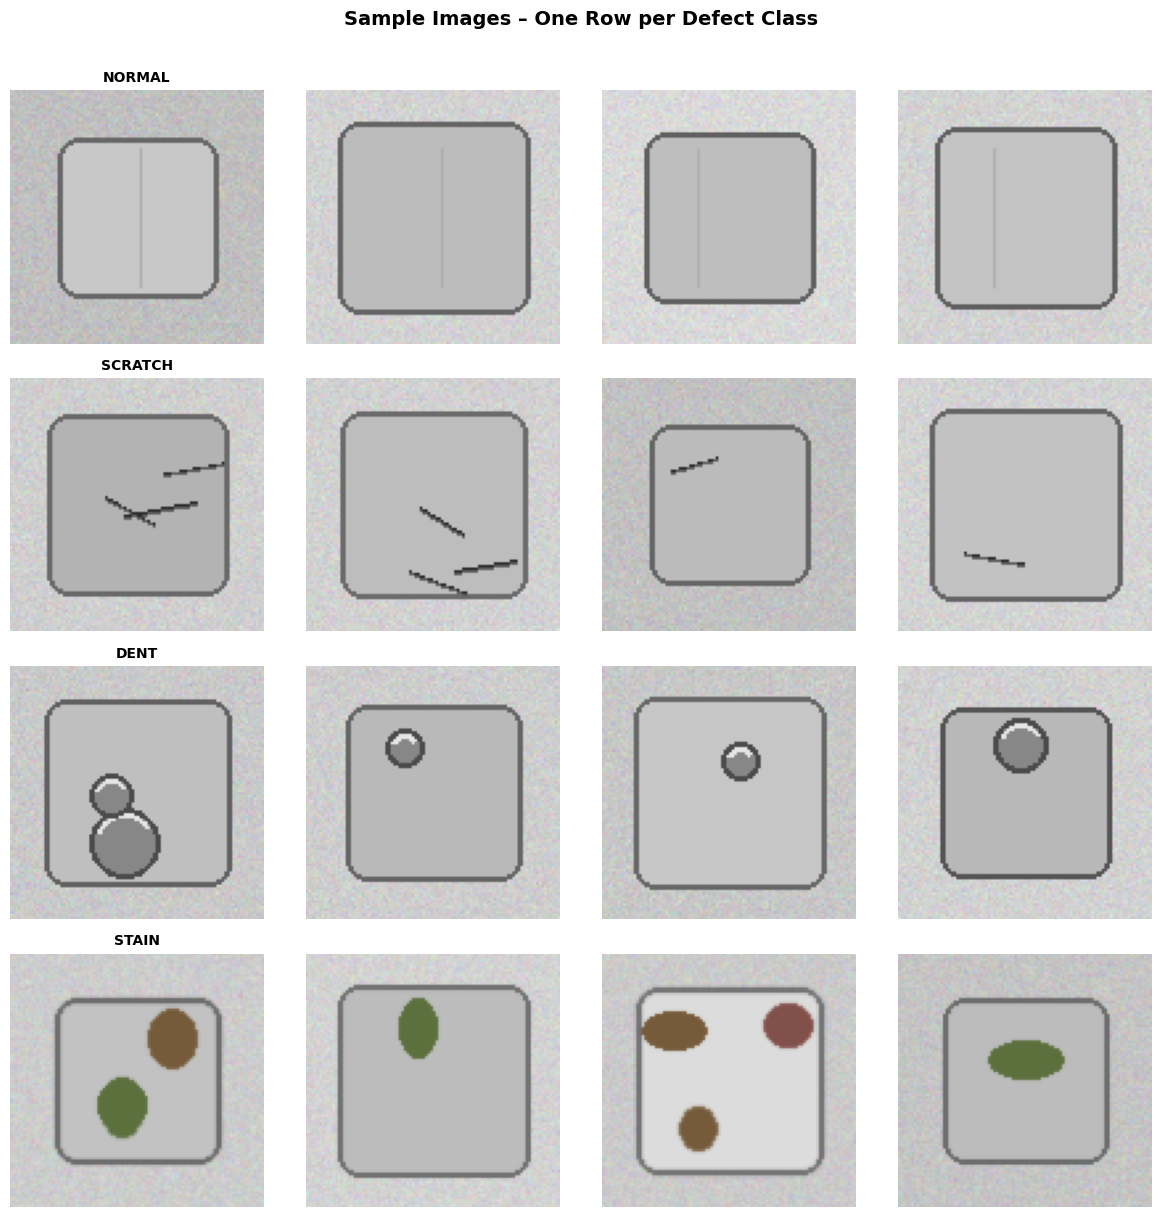

In [6]:
# ── Cell 6: Sample Images per Class ───────────────────────────────────────────
N = 4
fig, axes = plt.subplots(len(CLASS_NAMES), N, figsize=(N*3, len(CLASS_NAMES)*3))

for row, cls in enumerate(CLASS_NAMES):
    cls_files = df[df['class'] == cls]['filename'].sample(N, random_state=SEED).tolist()
    for col, rel_path in enumerate(cls_files):
        full = os.path.join(DATASET_DIR, rel_path)
        img = Image.open(full).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls.upper() if col == 0 else '', fontweight='bold', fontsize=10)
        axes[row][col].axis('off')

plt.suptitle('Sample Images – One Row per Defect Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3: Image Preprocessing

In [7]:
# ── Cell 7: Data Generators ────────────────────────────────────────────────────
# Preprocessing steps applied:
#   1. Resize to 128x128
#   2. Normalize pixels to [0, 1]  (rescale = 1/255)
#   3. 80/20 train/val split
#   4. Augmentation on training data only

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    IMG_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    IMG_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

NUM_CLASSES  = len(train_gen.class_indices)
IDX_TO_CLASS = {v: k for k, v in train_gen.class_indices.items()}

print(f"Training samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")
print(f"Class indices      : {train_gen.class_indices}")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Training samples   : 384
Validation samples : 96
Class indices      : {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


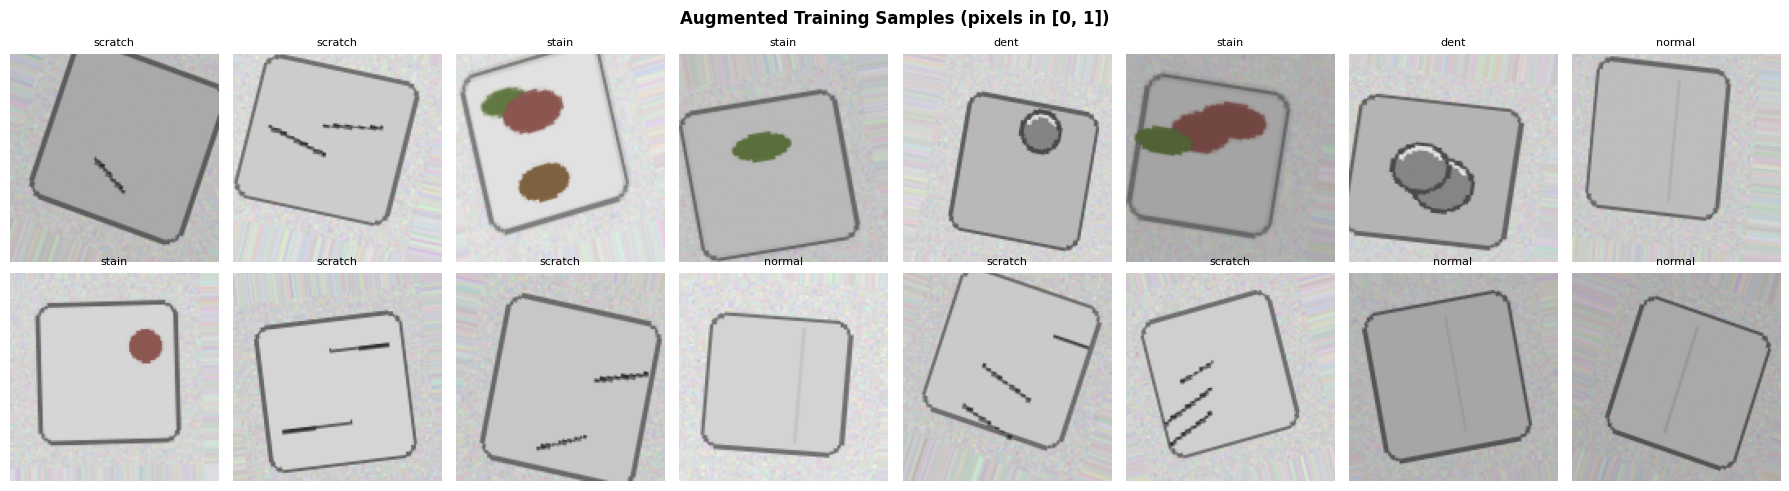

In [8]:
# ── Cell 8: Visualise Augmented Samples ────────────────────────────────────────
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(imgs[i % len(imgs)])
    ax.set_title(IDX_TO_CLASS[np.argmax(labels[i % len(labels)])], fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Samples (pixels in [0, 1])', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/augmented_samples.png', dpi=150)
plt.show()

## Task 4: CNN Model Creation

In [9]:
# ── Cell 9: Build CNN ─────────────────────────────────────────────────────────
def build_cnn(input_shape, num_classes):
    model = models.Sequential(name='ManufacturingDefect_CNN')
    model.add(layers.Input(shape=input_shape))

    # Block 1 – low-level: edges, color gradients
    model.add(layers.Conv2D(32, (3,3), padding='same'))   # Convolution layer
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))                   # Activation function
    model.add(layers.MaxPooling2D((2,2)))                  # Pooling layer

    # Block 2 – mid-level: scratch patterns, textures
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 3 – higher: dent shapes, stain blobs
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 4 – abstract defect representations
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Classifier head
    model.add(layers.Flatten())          # Flatten layer
    model.add(layers.Dense(256))         # Dense layer
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128))
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


INPUT_SHAPE = IMG_SIZE + (3,)
model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "ManufacturingDefect_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,619,332 (17.62 MB)

 Trainable params: 4,617,860 (17.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [10]:
# ── Cell 10: Compile ──────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Total parameters: {model.count_params():,}")

Total parameters: 4,619,332


## Task 5: Model Training and Evaluation

In [11]:
# ── Cell 11: Train ────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.4590 - loss: 1.4334
Epoch 1: val_accuracy improved from None to 0.29167, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 838ms/step - accuracy: 0.5573 - loss: 1.1871 - val_accuracy: 0.2917 - val_loss: 1.5991 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.6574 - loss: 0.8527
Epoch 2: val_accuracy did not improve from 0.29167
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 694ms/step - accuracy: 0.6693 - loss: 0.8147 - val_accuracy: 0.2500 - val_loss: 2.3161 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.8053 - loss: 0.5738
Epoch 3: val_accuracy did not improve from 0.29167
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 666ms/step - accuracy: 0.8073 - loss: 0.5534 - val_accuracy: 0.2500 - val_loss: 2.8600 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8241 - loss:

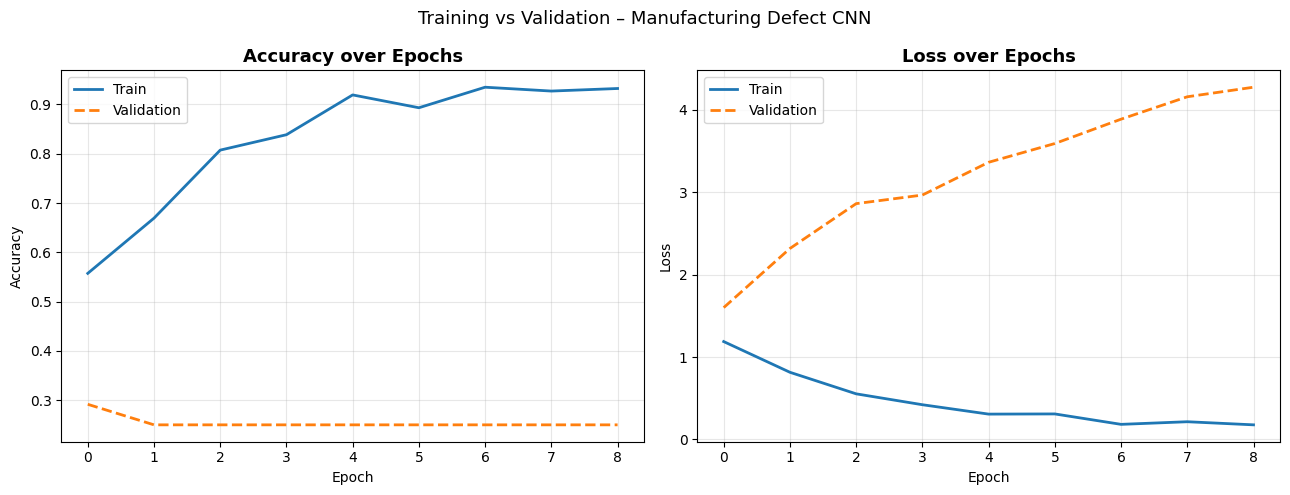

Best Validation Accuracy: 29.17%


In [12]:
# ── Cell 12: Accuracy / Loss Curves ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
ax1.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
ax2.set_title('Loss over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training vs Validation – Manufacturing Defect CNN', fontsize=13)
plt.tight_layout()
plt.savefig('./results/accuracy_loss_curves.png', dpi=150)
plt.show()
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step

Classification Report:
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.27      1.00      0.42        24
     scratch       0.00      0.00      0.00        24
       stain       0.67      0.17      0.27        24

    accuracy                           0.29        96
   macro avg       0.23      0.29      0.17        96
weighted avg       0.23      0.29      0.17        96



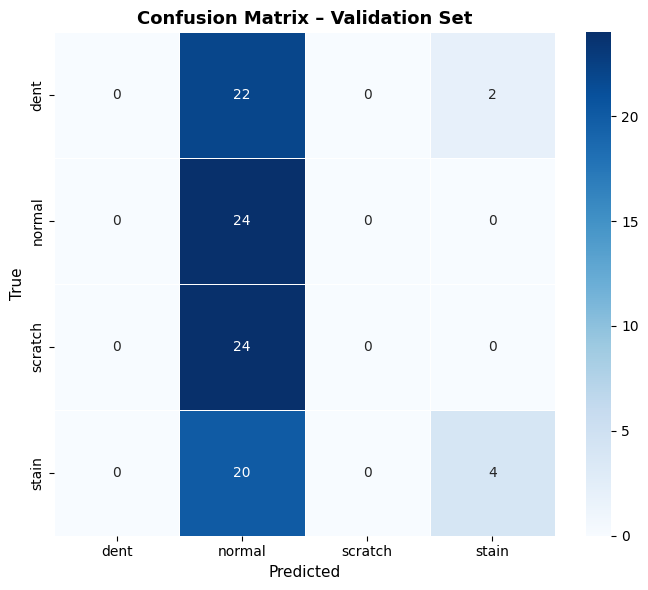

In [13]:
# ── Cell 13: Confusion Matrix & Classification Report ─────────────────────────
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = val_gen.classes
labels_list = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels_list))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix – Validation Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
plt.tight_layout()
plt.savefig('./results/confusion_matrix.png', dpi=150)
plt.show()

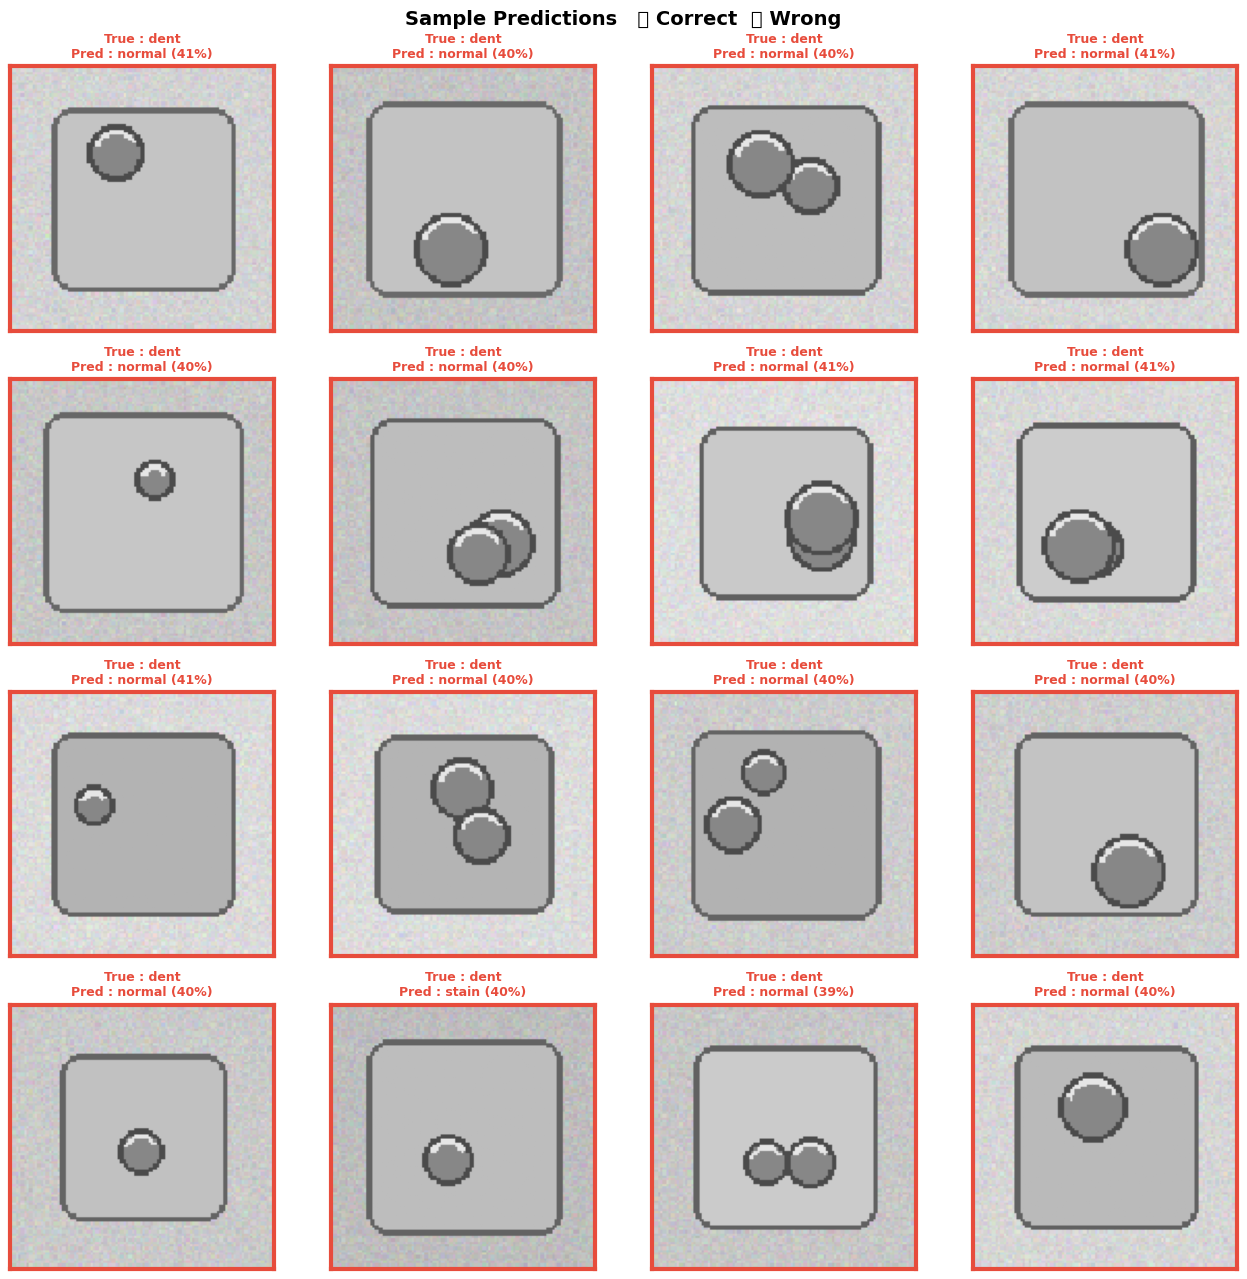

Batch accuracy: 0.00%


In [14]:
# ── Cell 14: Sample Predictions ───────────────────────────────────────────────
val_gen.reset()
batch_imgs, batch_labels = next(val_gen)
preds_prob = model.predict(batch_imgs, verbose=0)
preds      = np.argmax(preds_prob, axis=1)
trues      = np.argmax(batch_labels, axis=1)

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
axes = axes.ravel()

for i in range(n_show):
    ax = axes[i]
    true_lbl = IDX_TO_CLASS[trues[i]]
    pred_lbl = IDX_TO_CLASS[preds[i]]
    conf     = preds_prob[i][preds[i]]
    correct  = (trues[i] == preds[i])
    color    = '#2ecc71' if correct else '#e74c3c'

    ax.imshow(batch_imgs[i])
    ax.set_title(f"True : {true_lbl}\nPred : {pred_lbl} ({conf:.0%})",
                 color=color, fontsize=9, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Sample Predictions   ✅ Correct  ❌ Wrong', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./sample_predictions/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Batch accuracy: {np.mean(trues[:n_show]==preds[:n_show]):.2%}")

In [15]:
# ── Cell 15: Final Summary ────────────────────────────────────────────────────
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
print("\n" + "="*45)
print("        FINAL MODEL PERFORMANCE")
print("="*45)
print(f"  Validation Accuracy : {val_acc*100:.2f}%")
print(f"  Validation Loss     : {val_loss:.4f}")
print(f"  Total Parameters    : {model.count_params():,}")
print(f"  Classes             : {labels_list}")
print("="*45)


        FINAL MODEL PERFORMANCE
  Validation Accuracy : 29.17%
  Validation Loss     : 1.5991
  Total Parameters    : 4,619,332
  Classes             : ['dent', 'normal', 'scratch', 'stain']


## Task 6: CNN Concept Explanation

### What is Convolution?
A small **filter (kernel)** — e.g., 3×3 pixels — slides across the image and computes a dot product at each position, producing a **feature map** that highlights where specific patterns (edges, scratches, blobs) appear. Multiple filters detect different patterns simultaneously. In deeper layers, filters combine simple features into complex ones like full defect shapes.

### Why is Pooling Used?
**MaxPooling** takes the maximum value in a small window (2×2), reducing the feature map size by half. This:
- Reduces computation for downstream layers
- Provides **translation invariance** — a scratch shifted slightly produces the same pooled output
- Acts as a regulariser by discarding fine-grained noise

### Why is ReLU Commonly Used?
**ReLU** = max(0, x). It:
- Introduces **non-linearity** so the network can learn complex patterns, not just linear combinations
- Is computationally cheap (just a threshold at zero)
- Avoids the **vanishing gradient** problem that occurs with sigmoid/tanh in deep networks
- Produces sparse activations, which implicitly regularises the model

### Why CNNs Are Better Than Regular Networks for Images?

| Property | MLP (Regular NN) | CNN |
|---|---|---|
| **Connections** | Every pixel → every neuron (millions of weights) | Small filter shared across positions (few weights) |
| **Spatial awareness** | None — image flattened to 1-D | Preserved — 2-D structure maintained |
| **Translation invariance** | No | Yes, via pooling |
| **Feature hierarchy** | No | Edges → textures → shapes → defects |
| **Scalability** | Breaks for large images | Efficient even on high-resolution inputs |

---

## Task 7: Business Use Case Mapping

### Domain: Manufacturing 🏭

**Use Case: Automated Visual Quality Inspection on the Production Line**

This CNN prototype directly mirrors a real industrial problem — detecting surface defects (scratches, dents, stains) on manufactured products.

**How it works in production:**
1. A high-resolution camera captures images of products moving along a conveyor belt.
2. The CNN classifies each image in real time: **Normal / Scratch / Dent / Stain**.
3. Defective products are automatically flagged and diverted before shipping.

**Business Impact:**
- Replaces slow, error-prone manual inspection with consistent 24/7 automation.
- Reduces defect escape rate, warranty claims, and customer complaints.
- Cuts quality-control labour costs significantly.
- Generates data logs for root-cause analysis of recurring defect types.

**Real-world examples:** BMW uses CNN-based defect detection on car body panels; Samsung applies it to display screen QC; Foxconn for PCB inspection.